In [7]:
print("Python is working!")

Python is working!


In [8]:
import pandas as pd

df = pd.read_csv("../data/emotion_cleaned.csv")

df.head()

,text,label,clean_text
0,All mutations are potentially harmful. Especia...,neutral,all mutations are potentially harmful. especia...
1,"Enfp male here, I would love to find an INTJ g...",love,"enfp male here, i would love to find an intj g..."
2,Thank you for doing your service. The world is...,gratitude,thank you for doing your service. the world is...
3,> That shit happens all the time with cabs. No...,disapproval,> that shit happens all the time with cabs. no...
4,I’m hoping so. I either make peace with it or ...,optimism,i’m hoping so. i either make peace with it or ...


In [9]:
df.shape


(10000, 3)

In [10]:
df["label"].value_counts()

label
neutral           1000
love               500
gratitude          500
disapproval        500
optimism           500
amusement          500
joy                500
anger              500
caring             500
excitement         500
disappointment     500
curiosity          500
surprise           500
realization        500
confusion          500
sadness            500
approval           500
admiration         500
annoyance          500
Name: count, dtype: int64

In [11]:
df.isnull().sum()

text           0
label          0
clean_text    23
dtype: int64

In [12]:
df = df.dropna(subset=['clean_text'])

print(df.isnull().sum())
print("Dataset shape:", df.shape)

text          0
label         0
clean_text    0
dtype: int64
Dataset shape: (9977, 3)


In [13]:
X = df['clean_text']
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9977,)
y shape: (9977,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7981,)
Testing data: (1996,)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (7981, 10000)
Testing TF-IDF shape: (1996, 10000)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.44438877755511025

Classification Report:
                precision    recall  f1-score   support

    admiration       0.58      0.52      0.55       100
     amusement       0.83      0.67      0.74       100
         anger       0.62      0.45      0.52       100
     annoyance       0.16      0.06      0.09       100
      approval       0.32      0.19      0.24       100
        caring       0.41      0.45      0.43        99
     confusion       0.53      0.40      0.46       100
     curiosity       0.45      0.37      0.40       100
disappointment       0.32      0.18      0.23       100
   disapproval       0.36      0.32      0.34       100
    excitement       0.54      0.31      0.39       100
     gratitude       0.99      0.88      0.93        99
           joy       0.54      0.53      0.53        99
          love       0.75      0.80      0.77        99
       neutral       0.19      0.56      0.28       200
      optimism       0.66    

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.2725450901803607

Classification Report:
                precision    recall  f1-score   support

    admiration       0.76      0.25      0.38       100
     amusement       0.83      0.24      0.37       100
         anger       0.78      0.29      0.42       100
     annoyance       0.00      0.00      0.00       100
      approval       0.71      0.05      0.09       100
        caring       0.44      0.11      0.18        99
     confusion       0.68      0.17      0.27       100
     curiosity       0.50      0.07      0.12       100
disappointment       0.40      0.02      0.04       100
   disapproval       0.40      0.02      0.04       100
    excitement       0.77      0.23      0.35       100
     gratitude       0.94      0.73      0.82        99
           joy       0.52      0.27      0.36        99
          love       0.78      0.46      0.58        99
       neutral       0.12      0.94      0.22       200
      optimism       0.65      0.24   

In [18]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.4283567134268537

Classification Report:
                precision    recall  f1-score   support

    admiration       0.53      0.55      0.54       100
     amusement       0.65      0.64      0.65       100
         anger       0.47      0.48      0.47       100
     annoyance       0.13      0.11      0.12       100
      approval       0.34      0.26      0.29       100
        caring       0.42      0.46      0.44        99
     confusion       0.40      0.33      0.36       100
     curiosity       0.36      0.36      0.36       100
disappointment       0.23      0.21      0.22       100
   disapproval       0.29      0.30      0.29       100
    excitement       0.47      0.40      0.43       100
     gratitude       0.96      0.88      0.92        99
           joy       0.44      0.48      0.46        99
          love       0.68      0.82      0.74        99
       neutral       0.18      0.21      0.20       200
      optimism       0.58      0.59      0.59 

In [19]:
results = {
    "Logistic Regression": lr_accuracy,
    "Naive Bayes": nb_accuracy,
    "SVM": svm_accuracy
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Logistic Regression: 0.4444
Naive Bayes: 0.2725
SVM: 0.4284


In [20]:
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model
}

accuracies = {
    "Logistic Regression": lr_accuracy,
    "Naive Bayes": nb_accuracy,
    "SVM": svm_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])

Best Model: Logistic Regression
Best Accuracy: 0.44438877755511025


In [21]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.444389
2,SVM,0.428357
1,Naive Bayes,0.272545


Matplotlib is building the font cache; this may take a moment.


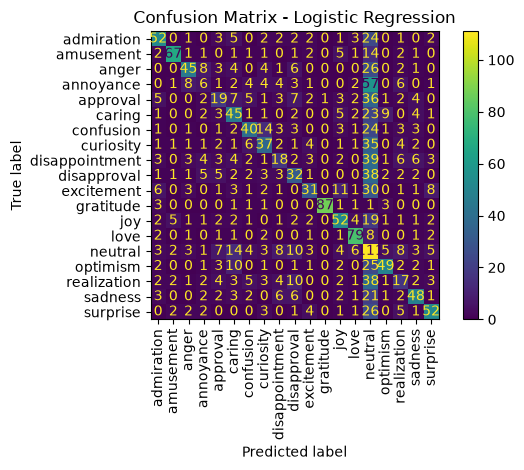

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_pred = best_model.predict(X_test_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    xticks_rotation=90
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [30]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/emotion_model.pkl")
joblib.dump(tfidf, "../models/emotion_vectorizer.pkl")

print("Best model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Best model saved successfully!
TF-IDF vectorizer saved successfully!


In [31]:
import os

print("Model exists:", os.path.exists("../models/emotion_model.pkl"))
print("TF-IDF exists:", os.path.exists("../models/emotion_vectorizer.pkl"))

Model exists: True
TF-IDF exists: True


In [ ]:
import joblib


loaded_model = joblib.load("../models/emotion_model.pkl")
loaded_tfidf = joblib.load("../models/emotion_vectorizer.pkl")


new_text = ["I am very happy and excited today"]


new_text_tfidf = loaded_tfidf.transform(new_text)


prediction = loaded_model.predict(new_text_tfidf)

print("Text:", new_text[0])
print("Predicted Emotion:", prediction[0])

Text: I am very happy and excited today
Predicted Emotion: excitement
